In [2]:
import itertools
import random
import time
import copy
import os
from functools import reduce
from collections import defaultdict

import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models
from torchvision.transforms import v2, transforms
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

Input Image Size: (st1 - 20 = 700 × 605) - (st21-40 = 565 × 584)
Ground Truth Size: same

In [3]:
# DATA_DIR = '/kaggle/input/retinal-vessels/all_label'
DATA_DIR = './retinal_vessels/all_label/'
IMAGES_ADDRESS = os.path.join(DATA_DIR, 'Images')
MASKS_ADDRESS = os.path.join(DATA_DIR, 'Labels')
image = np.array(plt.imread(os.path.join(IMAGES_ADDRESS, 'st01.jpg')))
mask = np.array(plt.imread(os.path.join(MASKS_ADDRESS, 'st_label01.jpg')))
print(f'Shapes are {image.shape} and {mask.shape}, so 3D and 2D')

Shapes are (605, 700, 3) and (605, 700, 3), so 3D and 2D


In [4]:
assert len(os.listdir(IMAGES_ADDRESS)) == len(os.listdir(MASKS_ADDRESS))

In [5]:
random_image_idx = np.random.choice(40, 28, replace=False)
comp_image_idx = set(np.arange(40)) - set(random_image_idx)
print(f'Train Set Length: {len(random_image_idx)} Test Set Length: {len(comp_image_idx)}')

Train Set Length: 28 Test Set Length: 12


In [6]:
# np.array(sorted(os.listdir(IMAGES_ADDRESS)))[random_image_idx]
# np.array(sorted(os.listdir(MASKS_ADDRESS)))[random_image_idx]

In [7]:
def get_split_data(image_address, mask_address, max_len, size):
    random_image_idx = np.random.choice(max_len, size, replace=False)
    comp_image_idx = np.array(list(set(np.arange(max_len)) - set(random_image_idx)))
    print(f'Train Set Length: {len(random_image_idx)} Test Set Length: {len(comp_image_idx)}')
    image_train = np.array(sorted(os.listdir(image_address)))[random_image_idx]
    image_test = np.array(sorted(os.listdir(image_address)))[comp_image_idx]
    mask_train = np.array(sorted(os.listdir(mask_address)))[random_image_idx]
    mask_test = np.array(sorted(os.listdir(mask_address)))[comp_image_idx]
    return image_train, image_test, mask_train, mask_test

In [8]:
def get_index_address(indcies, address):
    full_addresses = []
    for i in indcies:
        full_addresses.append(os.path.join(address, i))
    return full_addresses

In [9]:
X_train, X_test, y_train, y_test = get_split_data(IMAGES_ADDRESS, MASKS_ADDRESS, 40, 28)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

Train Set Length: 28 Test Set Length: 12
['st05.jpg' 'st40.jpg' 'st36.jpg' 'st07.jpg' 'st13.jpg' 'st06.jpg'
 'st30.jpg' 'st11.jpg' 'st19.jpg' 'st17.jpg' 'st29.jpg' 'st39.jpg'
 'st20.jpg' 'st35.jpg' 'st15.jpg' 'st22.jpg' 'st08.jpg' 'st24.jpg'
 'st18.jpg' 'st01.jpg' 'st26.jpg' 'st32.jpg' 'st16.jpg' 'st09.jpg'
 'st38.jpg' 'st34.jpg' 'st03.jpg' 'st27.jpg']
['st33.jpg' 'st02.jpg' 'st04.jpg' 'st37.jpg' 'st10.jpg' 'st12.jpg'
 'st14.jpg' 'st21.jpg' 'st23.jpg' 'st25.jpg' 'st28.jpg' 'st31.jpg']
['st_label05.jpg' 'st_label40.jpg' 'st_label36.jpg' 'st_label07.jpg'
 'st_label13.jpg' 'st_label06.jpg' 'st_label30.jpg' 'st_label11.jpg'
 'st_label19.jpg' 'st_label17.jpg' 'st_label29.jpg' 'st_label39.jpg'
 'st_label20.jpg' 'st_label35.jpg' 'st_label15.jpg' 'st_label22.jpg'
 'st_label08.jpg' 'st_label24.jpg' 'st_label18.jpg' 'st_label01.jpg'
 'st_label26.jpg' 'st_label32.jpg' 'st_label16.jpg' 'st_label09.jpg'
 'st_label38.jpg' 'st_label34.jpg' 'st_label03.jpg' 'st_label27.jpg']
['st_label33.jpg' 'st_labe

In [10]:
image_train_address = get_index_address(X_train, IMAGES_ADDRESS)
image_test_address = get_index_address(X_test, IMAGES_ADDRESS)
mask_train_address = get_index_address(y_train, MASKS_ADDRESS)
mask_test_address = get_index_address(y_test, MASKS_ADDRESS)

In [11]:
mask_test_address

['./retinal_vessels/all_label/Labels/st_label33.jpg',
 './retinal_vessels/all_label/Labels/st_label02.jpg',
 './retinal_vessels/all_label/Labels/st_label04.jpg',
 './retinal_vessels/all_label/Labels/st_label37.jpg',
 './retinal_vessels/all_label/Labels/st_label10.jpg',
 './retinal_vessels/all_label/Labels/st_label12.jpg',
 './retinal_vessels/all_label/Labels/st_label14.jpg',
 './retinal_vessels/all_label/Labels/st_label21.jpg',
 './retinal_vessels/all_label/Labels/st_label23.jpg',
 './retinal_vessels/all_label/Labels/st_label25.jpg',
 './retinal_vessels/all_label/Labels/st_label28.jpg',
 './retinal_vessels/all_label/Labels/st_label31.jpg']

In [12]:
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_target_size = (512, 512), transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_target_size = image_target_size

        self.image_list = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
        self.mask_list = sorted([f for f in os.listdir(mask_dir) if f.endswith('.jpg')])

        
    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_list[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_list[idx])  # assuming masks have the same filename
        image = Image.open(img_path).convert("RGB")
        image = image.resize(self.image_target_size, Image.BILINEAR)

        mask = Image.open(mask_path).convert("L")  # single-channel for mask
        mask = mask.resize(self.image_target_size, Image.BILINEAR)

        image = transforms.ToTensor()(image)
        mask = torch.tensor(np.array(mask), dtype=torch.long)
        
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = (mask > 0.5).float()  # Binarize mask (0 or 1)

        return image, mask

In [13]:
class SplitSegmentationDataset(Dataset):
    def __init__(self, image_address, mask_address, image_target_size = (512, 512), transform=None):
        # self.image_dir = image_dir
        # self.mask_dir = mask_dir
        self.transform = transform
        self.image_target_size = image_target_size
        self.image_list = image_address
        self.mask_list = mask_address

        
    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        # img_path = os.path.join(self.image_dir, self.image_list[idx])
        # mask_path = os.path.join(self.mask_dir, self.mask_list[idx])  # assuming masks have the same filename
        img_path = self.image_list[idx]
        mask_path = self.mask_list[idx]
        image = Image.open(img_path).convert("RGB")
        image = image.resize(self.image_target_size, Image.BILINEAR)
        mask = Image.open(mask_path).convert("L")  # single-channel for mask
        mask = mask.resize(self.image_target_size, Image.BILINEAR)

        image = transforms.ToTensor()(image)
        mask = torch.tensor(np.array(mask), dtype=torch.long)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            mask = (mask > 0.5).float()  # Binarize mask (0 or 1)

        return image, mask

In [14]:
# mask_train_address
train_dataset = SplitSegmentationDataset(image_train_address, mask_train_address)
test_dataset = SplitSegmentationDataset(image_test_address, mask_test_address)
train_dataset[0]

(tensor([[[0.0118, 0.0118, 0.0157,  ..., 0.0078, 0.0078, 0.0078],
          [0.0118, 0.0118, 0.0157,  ..., 0.0118, 0.0118, 0.0078],
          [0.0118, 0.0118, 0.0157,  ..., 0.0157, 0.0157, 0.0118],
          ...,
          [0.0235, 0.0275, 0.0235,  ..., 0.0157, 0.0157, 0.0118],
          [0.0275, 0.0314, 0.0235,  ..., 0.0157, 0.0118, 0.0118],
          [0.0235, 0.0275, 0.0157,  ..., 0.0157, 0.0118, 0.0078]],
 
         [[0.0000, 0.0000, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
          [0.0000, 0.0000, 0.0039,  ..., 0.0078, 0.0078, 0.0039],
          [0.0000, 0.0000, 0.0039,  ..., 0.0118, 0.0118, 0.0078],
          ...,
          [0.0000, 0.0039, 0.0000,  ..., 0.0039, 0.0039, 0.0078],
          [0.0039, 0.0078, 0.0000,  ..., 0.0039, 0.0078, 0.0078],
          [0.0118, 0.0157, 0.0039,  ..., 0.0039, 0.0078, 0.0118]],
 
         [[0.0353, 0.0353, 0.0392,  ..., 0.0235, 0.0235, 0.0235],
          [0.0353, 0.0353, 0.0392,  ..., 0.0314, 0.0314, 0.0275],
          [0.0353, 0.0353, 0.0392,  ...,

In [15]:
# def get_dataloaders():
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#     ])
#     train_loader = DataLoader(SegmentationDataset(IMAGES_ADDRESS, MASKS_ADDRESS, transform=transform), 
#                           batch_size=8, shuffle=True, pin_memory=True)
#     return train_loader

# get_dataloaders()

In [16]:
def calculate_metrics(outputs, masks, threshold=0.5):
    preds = (outputs > threshold).float()
    masks = (masks > 0.5).float()  # Ensure masks are binary
    
    # Flatten tensors for metric calculations
    preds = preds.view(-1)
    masks = masks.view(-1)
    
    # True Positives, False Positives, False Negatives, True Negatives
    tp = (preds * masks).sum().item()
    fp = (preds * (1 - masks)).sum().item()
    fn = ((1 - preds) * masks).sum().item()
    tn = ((1 - preds) * (1 - masks)).sum().item()
    
    # Accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    
    # Sensitivity (Recall)
    sensitivity = tp / (tp + fn + 1e-8)
    
    # Precision
    precision = tp / (tp + fp + 1e-8)
    # print(f'Acc: {accuracy};Sens: {sensitivity}; Precision: {precision}')
    
    # F1 Score
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity + 1e-8)
    
    return accuracy, sensitivity, f1

In [17]:
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice


class JaccardLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        intersection = (inputs * targets).sum()
        union = inputs.sum() + targets.sum()
        jaccard = (intersection + smooth) / (union - intersection + smooth)
        return 1 - jaccard

In [18]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        
        def upconv_block(in_ch, out_ch):
            return nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        
        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.bottleneck = conv_block(512, 1024)
        
        # Decoder
        self.up4 = upconv_block(1024, 512)
        self.dec4 = conv_block(1024, 512)
        self.up3 = upconv_block(512, 256)
        self.dec3 = conv_block(512, 256)
        self.up2 = upconv_block(256, 128)
        self.dec2 = conv_block(256, 128)
        self.up1 = upconv_block(128, 64)
        self.dec1 = conv_block(128, 64)
        
        # Final convolution
        self.final_conv = nn.Conv2d(64, out_channels, 1)
        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        
        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return torch.sigmoid(self.final_conv(d1))

## 1. A. Training and plotting F1, Accuracy, Sensitivity

In [19]:
def plot_metric(loss, accuracy, sensitivity, f1):
    
    fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(nrows=2, ncols=2)
    ax1.set_title('Loss')
    ax1.plot(loss)
    
    ax2.set_title('Accuracy')
    ax2.plot(accuracy)
    
    ax3.set_title('Sensitivity')
    ax3.plot(sensitivity)
    
    ax4.set_title('F1')
    ax4.plot(f1)

In [20]:
def train_model(model, dataloader, criterion, optimizer, device, num_epochs=20):
    model.train()
    print('Starting')
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs}')
        # Report F1, Sensitivity, Accuracy
        running_loss = 0.0
        running_accuracy = 0.0
        running_sensitivity = 0.0
        running_f1 = 0.0
        total_samples = 0
        
        list_epoch_loss = []
        list_epoch_accuracy = []
        list_epoch_sensitivity = []
        list_epoch_f1 = []
        
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            # loss = criterion2(outputs, masks) # Using sum of 2 criterions were not a good decision.
            # loss = DiceLoss()(outputs, masks)
            loss.backward()
            optimizer.step()
            
            accuracy, sensitivity, f1 = calculate_metrics(outputs, masks)
            
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_accuracy += accuracy * batch_size
            running_sensitivity += sensitivity * batch_size
            running_f1 += f1 * batch_size
            total_samples += batch_size
        
        epoch_loss = running_loss / total_samples
        epoch_accuracy = running_accuracy / total_samples
        epoch_sensitivity = running_sensitivity / total_samples
        epoch_f1 = running_f1 / total_samples
        
        list_epoch_loss.append(epoch_loss)
        list_epoch_accuracy.append(epoch_accuracy)
        list_epoch_sensitivity.append(epoch_sensitivity)
        list_epoch_f1.append(epoch_f1)
        
        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Loss: {epoch_loss:.4f}, '
              f'Accuracy: {epoch_accuracy:.4f}, '
              f'Sensitivity: {epoch_sensitivity:.4f}, '
              f'F1 Score: {epoch_f1:.4f}')

In [30]:
# Main Execution
if __name__ == '__main__':
    # Hyperparameters
    batch_size = 8
    learning_rate = 1e-6
    num_epochs = 10
    image_size = 512
    mode='split'
    
    # Device configuration
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Data transforms
    transform = transforms.Compose([
        # v2.ToImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])
    
    # Dataset and DataLoader
    # Replace with your dataset paths
    if mode == 'full':
        # DATA_DIR = '/kaggle/input/retinal-vessels/all_label'
        DATA_DIR = './retinal_vessels/all_label/'
        IMAGES_ADDRESS = os.path.join(DATA_DIR, 'Images')
        MASKS_ADDRESS = os.path.join(DATA_DIR, 'Labels')
        dataset = SegmentationDataset(IMAGES_ADDRESS, MASKS_ADDRESS, transform=transform)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    elif mode == 'split':
        # DATA_DIR = '/kaggle/input/retinal-vessels/all_label'
        # IMAGES_ADDRESS = os.path.join(DATA_DIR, 'Images')
        # MASKS_ADDRESS = os.path.join(DATA_DIR, 'Labels')
        # dataset = SegmentationDataset(IMAGES_ADDRESS, MASKS_ADDRESS, transform=transform)
        dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
    
    # Model, Loss, Optimizer
    model = ModifiedUNet(in_channels=3, out_channels=1).to(device)
    
    # criterion = nn.BCEWithLogitsLoss()
    # criterion = DiceLoss()
    criterion = JaccardLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    train_model(model, dataloader, criterion, optimizer, device, num_epochs)
    
    # Save the model
    torch.save(model.state_dict(), 'unet_model.pth')

Starting
Epoch 0/10
torch.Size([8, 128, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 192, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 128, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 192, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 128, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 192, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([4, 128, 512, 512])
torch.Size([4, 64, 512, 512])
torch.Size([4, 192, 512, 512])
torch.Size([4, 64, 512, 512])
Epoch 1/10, Loss: 2.3247, Accuracy: 0.7480, Sensitivity: 0.0000, F1 Score: 0.0000
Epoch 1/10
torch.Size([8, 128, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 192, 512, 512])


KeyboardInterrupt: 

In [21]:
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### Model Evaluation

In [31]:
model.eval()
val_loss = 0.0
val_accuracy = 0.0
val_sensitivity = 0.0
val_f1 = 0.0
val_samples = 0
predictied_mask =None

with torch.no_grad():
    for images, masks in test_dataloader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        accuracy, sensitivity, f1 = calculate_metrics(outputs, masks)
        
        batch_size = images.size(0)
        
        val_loss += loss.item() * batch_size
        val_accuracy += accuracy * batch_size
        val_sensitivity += sensitivity * batch_size
        val_f1 += f1 * batch_size
        val_samples += batch_size

    val_loss = val_loss / val_samples
    val_accuracy = val_accuracy / val_samples
    val_sensitivity = val_sensitivity / val_samples
    val_f1 = val_f1 / val_samples

print(f'Validation Loss: {val_loss:.4f}, '
      f'Val Acc: {val_accuracy:.4f}, Sens: {val_sensitivity:.4f}, F1: {val_f1:.4f}')


torch.Size([8, 128, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([8, 192, 512, 512])
torch.Size([8, 64, 512, 512])
torch.Size([4, 128, 512, 512])
torch.Size([4, 64, 512, 512])
torch.Size([4, 192, 512, 512])
torch.Size([4, 64, 512, 512])
Validation Loss: 2.4108, Val Acc: 0.7967, Sens: 0.0000, F1: 0.0000


### GPU clearance for Kaggle (doesn't work)

In [ ]:
# torch.cuda.empty_cache()

# cuda.select_device(0)
# cuda.close()
# cuda.select_device(0)

## 1. B. Plotting the channels (green seems to be the best)

In [23]:
# Use this after training to get the predictited masks
for images, masks in test_dataloader:
    images, masks = images.to(device), masks.to(device)
    print(images.shape)
    # outputs = model(images)
    # single_out = outputs[0, 0].cpu().detach()
    mask = masks[0]
    image = images[0]
    dx = [image, mask]
    plot_channels_image_mask(dx)
    # plot_channels_image_mask(dx, single_out)
    break

NameError: name 'device' is not defined

In [24]:
def plot_channels_image_mask(data_example, pred_image = None):
    """
    Pick an exmaple from dataset and show it.
    """
    fig, [[ax1, ax2, ax3], [ax4, ax5, ax6]] = plt.subplots(nrows=2, ncols=3, figsize=(10, 8))
    # Get the data
    exp1 = data_example
    ax1.set_title('Mask/Ground Truth')
    ax1.imshow(exp1[1], cmap='gray')
    
    image = np.array(exp1[0])
    egami = np.moveaxis(image, 0, -1)
    ax2.set_title('Image')
    ax2.imshow(egami, cmap='gray')
    if pred_image:
        ax3.imshow(pred_image)
    ax4.set_title('R')
    ax5.set_title('G')
    ax6.set_title('B')
    
    # Ran experiments on Blue + Green
    # new_channel_gb = (exp1[0][0] * exp1[0][1])
    # Maybe add another channel?
    # ax3.imshow(-1*new_channel_gb, cmap='binary')
    
    ax4.imshow(-1*exp1[0][0], cmap='Reds')
    ax5.imshow(-1*exp1[0][1], cmap='Greens')
    ax6.imshow(-1*exp1[0][2], cmap='Blues')

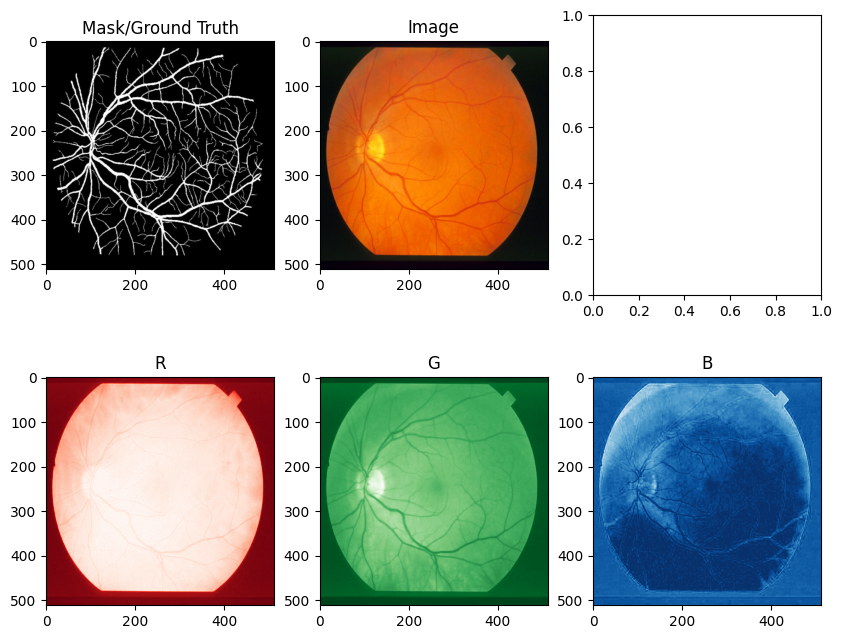

In [25]:
plot_channels_image_mask(train_dataset[7])

In [ ]:
plt.subplots(nrows=1, ncols=3)d

In [29]:
class ModifiedUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(ModifiedUNet, self).__init__()
        
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        
        def upconv_block(in_ch, out_ch):
            return nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        
        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.bottleneck = conv_block(512, 1024)
        
        # Decoder
        self.up4 = upconv_block(1024, 512)
        self.dec4 = conv_block(1024, 512)
        self.up3 = upconv_block(512, 256)
        self.dec3 = conv_block(512, 256)
        self.up2 = upconv_block(256, 128)
        self.dec2 = conv_block(256, 128)
        self.up1 = upconv_block(128, 64)
        self.dec1 = conv_block(192, 64)
        
        # Final convolution
        self.final_conv = nn.Conv2d(64, out_channels, 1)
        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e2_up = nn.ConvTranspose2d(128, 64, 2, stride=2)(e2)
        
        ex = torch.cat([e1, e2_up], dim=1)
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        
        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)

        # torch.Size([8, 128, 512, 512])
        # torch.Size([8, 64, 512, 512])
        # torch.Size([8, 192, 512, 512])
        print(ex.shape)
        print(d1.shape)
        d1 = torch.cat([d1, ex], dim=1)
        print(d1.shape)
        d1 = self.dec1(d1)
        print(d1.shape)
        
        return torch.sigmoid(self.final_conv(d1))

In [27]:
ModifiedUNet()

ModifiedUNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(512,